In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
df = pd.read_csv('../data/customer_churn.csv')

df.head(5)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


In [85]:
df.columns

Index(['Names', 'Age', 'Total_Purchase', 'Account_Manager', 'Years',
       'Num_Sites', 'Onboard_date', 'Location', 'Company', 'Churn'],
      dtype='str')

In [86]:
df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,0.166667
std,6.127560,2408.644532,0.499921,1.274449,1.764836,0.372885
min,22.000000,100.000000,0.000000,1.000000,3.000000,0.000000
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,0.000000
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,0.000000
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,0.000000
max,65.000000,18026.010000,1.000000,9.150000,14.000000,1.000000


In [87]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    str    
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    str    
 7   Location         900 non-null    str    
 8   Company          900 non-null    str    
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 70.4 KB


Need to change the dtype of   Onboard_date     900 non-null    str    to datetime

In [88]:
df["Onboard_date"] = pd.to_datetime(df["Onboard_date"], dayfirst=True, format='mixed')

In [89]:
df["Onboard_date"].dtype

dtype('<M8[us]')

In [90]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Names            900 non-null    str           
 1   Age              900 non-null    float64       
 2   Total_Purchase   900 non-null    float64       
 3   Account_Manager  900 non-null    int64         
 4   Years            900 non-null    float64       
 5   Num_Sites        900 non-null    float64       
 6   Onboard_date     900 non-null    datetime64[us]
 7   Location         900 non-null    str           
 8   Company          900 non-null    str           
 9   Churn            900 non-null    int64         
dtypes: datetime64[us](1), float64(4), int64(2), str(3)
memory usage: 70.4 KB


In [91]:
df.isnull().sum()

Names              0
Age                0
Total_Purchase     0
Account_Manager    0
Years              0
Num_Sites          0
Onboard_date       0
Location           0
Company            0
Churn              0
dtype: int64

In [92]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
895    False
896    False
897    False
898    False
899    False
Length: 900, dtype: bool

In [93]:
df.duplicated().sum()

np.int64(0)

In [94]:
df[df.duplicated()]

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn


In [95]:
print("Dataset cleaned")
print('Data format status: ', "Corrected", df["Onboard_date"].dtype)
print('Null values: ', df.isnull().sum().sum())
print("Duplicated values: ", df.duplicated().sum())

Dataset cleaned
Data format status:  Corrected datetime64[us]
Null values:  0
Duplicated values:  0


In [96]:
df.to_csv('../data/cleaned_customer_churn_3rdweek.csv')

Lets do feature engineering


In [97]:
df.columns

Index(['Names', 'Age', 'Total_Purchase', 'Account_Manager', 'Years',
       'Num_Sites', 'Onboard_date', 'Location', 'Company', 'Churn'],
      dtype='str')

In [98]:
df.groupby('Years')['Churn'].value_counts().sort_values(ascending=True)

Years  Churn
8.08   1        1
2.88   0        1
2.84   0        1
2.82   0        1
2.72   1        1
               ..
6.50   0        6
4.76   0        6
4.61   0        7
5.07   0        7
5.89   0        8
Name: count, Length: 509, dtype: int64

In [99]:
df.groupby('Num_Sites')['Churn'].value_counts().sort_values(ascending=True)

Num_Sites  Churn
6.0        1          1
14.0       0          1
7.0        1          2
3.0        0          2
4.0        0          4
12.0       0          5
14.0       1          5
8.0        1          8
13.0       1          8
9.0        1         19
5.0        0         22
12.0       1         27
10.0       1         34
11.0       0         37
           1         46
6.0        0         66
10.0       0         97
7.0        0        144
9.0        0        167
8.0        0        205
Name: count, dtype: int64

lets make interaction feature

In [100]:
df.columns

Index(['Names', 'Age', 'Total_Purchase', 'Account_Manager', 'Years',
       'Num_Sites', 'Onboard_date', 'Location', 'Company', 'Churn'],
      dtype='str')

In [101]:
df['year_x_num_sites'] = df['Years'] * df['Num_Sites']

df.head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,year_x_num_sites
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,57.76
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,71.50
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,80.04


lets make a categorical feature to see the tenure of the users

<Axes: xlabel='Years', ylabel='Count'>

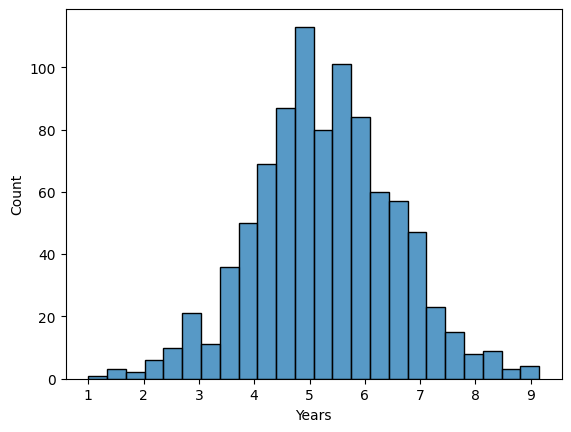

In [102]:
sns.histplot(df['Years'])

<Axes: xlabel='tenure_years', ylabel='Count'>

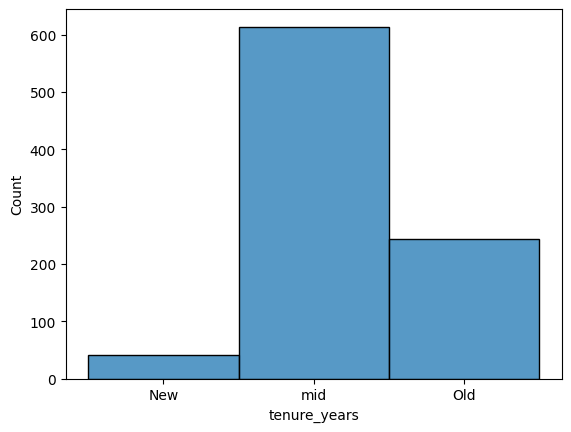

In [103]:
df['tenure_years'] = pd.cut(df['Years'], bins=[0,3,6,9], labels=['New','mid','Old'])

sns.histplot(df['tenure_years'])

In [104]:
df.head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,year_x_num_sites,tenure_years
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,57.76,Old
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,71.50,Old
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,80.04,Old


lets make a transformation feature using Total_Purchase and see if there are any outliers

<Axes: xlabel='Total_Purchase', ylabel='Count'>

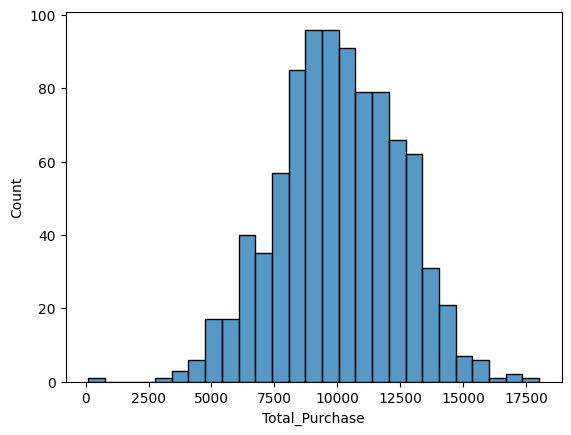

In [105]:
sns.histplot(df['Total_Purchase'])

<Axes: xlabel='log_Total_Purchase', ylabel='Count'>

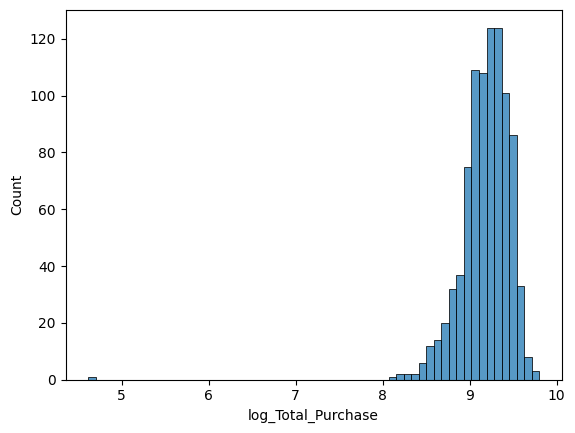

In [106]:
df['log_Total_Purchase'] = np.log1p(df['Total_Purchase'])

sns.histplot(df['log_Total_Purchase'] )

we got an outlier

In [107]:
df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Churn,year_x_num_sites,log_Total_Purchase
count,900.000000,900.000000,900.000000,900.000000,900.000000,900,900.000000,900.000000,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,2011-04-16 22:35:36.358888,0.166667,45.400711,9.181865
min,22.000000,100.000000,0.000000,1.000000,3.000000,2006-01-03 07:20:00,0.000000,10.000000,4.615121
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,2008-06-29 16:05:08,0.000000,34.930000,9.047600
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,2011-03-26 09:29:36.500000,0.000000,43.910000,9.215016
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,2014-02-24 19:50:14.750000,0.000000,53.470000,9.372553
max,65.000000,18026.010000,1.000000,9.150000,14.000000,2016-12-28 04:07:38,1.000000,101.500000,9.799626
std,6.127560,2408.644532,0.499921,1.274449,1.764836,NaN,0.372885,15.084907,0.298455


In [108]:
df.sort_values(by='log_Total_Purchase', ascending=True).head(4)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,year_x_num_sites,tenure_years,log_Total_Purchase
659,Kayla Reeves,38.0,100.00,0,5.27,5.0,2006-03-10 09:01:48,"1511 Porter Drive Amberberg, NC 44608",Stewart-Lopez,0,26.35,mid,4.615121
371,Justin Campos,53.0,3263.00,1,2.77,9.0,2013-11-11 22:49:58,"3483 Davis Viaduct Guzmanmouth, RI 60858",Hall-Butler,0,24.93,New,8.090709
448,Lori Medina,39.0,3676.68,1,3.52,9.0,2008-07-16 11:36:45,"PSC 1874, Box 9238 APO AP 68299","Garcia, Hansen and Austin",0,31.68,mid,8.210037
229,Kelly Terry,45.0,3689.95,1,5.01,11.0,2014-09-10 10:05:06,"3798 Johnson Gardens Hughesside, PR 65467","Ellis, Johnston and Sullivan",0,55.11,mid,8.213639


In [109]:
df = df.drop(659)

df.sort_values(by='log_Total_Purchase', ascending=True).head(4)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,year_x_num_sites,tenure_years,log_Total_Purchase
371,Justin Campos,53.0,3263.00,1,2.77,9.0,2013-11-11 22:49:58,"3483 Davis Viaduct Guzmanmouth, RI 60858",Hall-Butler,0,24.93,New,8.090709
448,Lori Medina,39.0,3676.68,1,3.52,9.0,2008-07-16 11:36:45,"PSC 1874, Box 9238 APO AP 68299","Garcia, Hansen and Austin",0,31.68,mid,8.210037
229,Kelly Terry,45.0,3689.95,1,5.01,11.0,2014-09-10 10:05:06,"3798 Johnson Gardens Hughesside, PR 65467","Ellis, Johnston and Sullivan",0,55.11,mid,8.213639
777,Kathleen Marquez,35.0,3825.70,0,4.28,8.0,2006-05-15 18:02:51,"984 Gallagher Circle Port Gregorytown, MD 59029","Steele, Nguyen and Lewis",0,34.24,mid,8.249758


In [110]:
df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Churn,year_x_num_sites,log_Total_Purchase
count,899.000000,899.000000,899.000000,899.000000,899.000000,899,899.000000,899.000000,899.000000
mean,41.820912,10073.906151,0.481646,5.273159,8.591769,2011-04-19 00:20:37.614015,0.166852,45.421902,9.186944
min,22.000000,3263.000000,0.000000,1.000000,3.000000,2006-01-03 07:20:00,0.000000,10.000000,8.090709
25%,38.000000,8508.135000,0.000000,4.450000,7.000000,2008-07-01 19:32:54.500000,0.000000,34.965000,9.048895
50%,42.000000,10050.610000,0.000000,5.210000,8.000000,2011-03-28 01:58:13,0.000000,43.920000,9.215488
75%,46.000000,11761.520000,1.000000,6.110000,10.000000,2014-02-24 22:13:10.500000,0.000000,53.480000,9.372673
max,65.000000,18026.010000,1.000000,9.150000,14.000000,2016-12-28 04:07:38,1.000000,101.500000,9.799626
std,6.129647,2386.917245,0.499941,1.275158,1.761750,NaN,0.373051,15.079895,0.256758


<Axes: xlabel='log_Total_Purchase', ylabel='Count'>

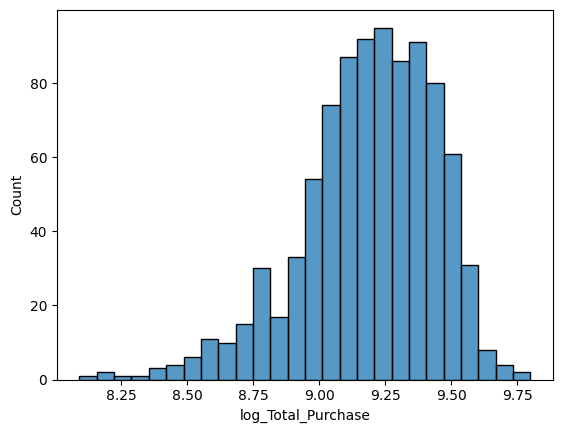

In [111]:
sns.histplot(df['log_Total_Purchase'] )

lets separate the feature and target data and make the test and train sets.


In [112]:
from sklearn.model_selection import train_test_split

In [113]:
df.columns

Index(['Names', 'Age', 'Total_Purchase', 'Account_Manager', 'Years',
       'Num_Sites', 'Onboard_date', 'Location', 'Company', 'Churn',
       'year_x_num_sites', 'tenure_years', 'log_Total_Purchase'],
      dtype='str')

In [114]:
X = df.drop("Churn", axis=1)

y = df['Churn']

print("shape of X: ",  X.shape)
print("Shape of y: ", y.shape)

shape of X:  (899, 12)
Shape of y:  (899,)


In [115]:
X.columns

Index(['Names', 'Age', 'Total_Purchase', 'Account_Manager', 'Years',
       'Num_Sites', 'Onboard_date', 'Location', 'Company', 'year_x_num_sites',
       'tenure_years', 'log_Total_Purchase'],
      dtype='str')

In [116]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=.20 , random_state=42)

print("shape of X_train: ",  X_train.shape)
print("Shape of X_test: ", X_test.shape)
print("shape of y_train: ",  y_train.shape)
print("Shape of y_test: ", y_test.shape)

shape of X_train:  (719, 12)
Shape of X_test:  (180, 12)
shape of y_train:  (719,)
Shape of y_test:  (180,)


lets separate the numeric and catergorical features.

In [117]:
X.info()

<class 'pandas.DataFrame'>
Index: 899 entries, 0 to 899
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Names               899 non-null    str           
 1   Age                 899 non-null    float64       
 2   Total_Purchase      899 non-null    float64       
 3   Account_Manager     899 non-null    int64         
 4   Years               899 non-null    float64       
 5   Num_Sites           899 non-null    float64       
 6   Onboard_date        899 non-null    datetime64[us]
 7   Location            899 non-null    str           
 8   Company             899 non-null    str           
 9   year_x_num_sites    899 non-null    float64       
 10  tenure_years        898 non-null    category      
 11  log_Total_Purchase  899 non-null    float64       
dtypes: category(1), datetime64[us](1), float64(6), int64(1), str(3)
memory usage: 85.3 KB


In [118]:
numeric_features = X.select_dtypes(
    include=['float64', 'int64']
).columns



In [119]:
numeric_features

Index(['Age', 'Total_Purchase', 'Account_Manager', 'Years', 'Num_Sites',
       'year_x_num_sites', 'log_Total_Purchase'],
      dtype='str')

In [120]:
numeric_features = numeric_features.drop('Account_Manager')

In [121]:
numeric_features

Index(['Age', 'Total_Purchase', 'Years', 'Num_Sites', 'year_x_num_sites',
       'log_Total_Purchase'],
      dtype='str')

In [122]:
categorical_features = ['Account_Manager', 'tenure_years']

In [123]:
categorical_features

['Account_Manager', 'tenure_years']

lets make the preprocessor, pipelines and ise columntransformers.

In [124]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [125]:
prepro = ColumnTransformer(
    transformers=(
            ('num', StandardScaler() ,numeric_features),
            ('cat', OneHotEncoder(drop= 'if_binary'), categorical_features)
    )
)

lets start with making model pipeline with selecting logistic regression as baseline

In [126]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [127]:
log_reg_pp = Pipeline([
    ('preprocessor', prepro),
        ('model', LogisticRegression())
])

In [128]:
log_reg_pp.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","(('num', ...), ...)"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [129]:
pred_log_reg = log_reg_pp.predict(X_test)

lets check the result with the help of classification report

In [130]:
from sklearn.metrics import classification_report

In [137]:
print('Classification report for logistic regression: \n', classification_report(y_test, pred_log_reg))

Classification report for logistic regression: 
               precision    recall  f1-score   support

           0       0.92      0.96      0.94       148
           1       0.76      0.59      0.67        32

    accuracy                           0.89       180
   macro avg       0.84      0.78      0.80       180
weighted avg       0.89      0.89      0.89       180



lets do knn classifier

In [132]:
from sklearn.neighbors import KNeighborsClassifier

In [133]:
knn_pp = Pipeline([
    ('preprocessor', prepro),
    ('Model', KNeighborsClassifier())
])

In [134]:
knn_pp.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('Model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","(('num', ...), ...)"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [136]:
pred_knn = knn_pp.predict(X_test)

In [138]:
print('Classification report for Knn Classifier: \n', classification_report(y_test, pred_knn))

Classification report for Knn Classifier: 
               precision    recall  f1-score   support

           0       0.87      0.94      0.91       148
           1       0.57      0.38      0.45        32

    accuracy                           0.84       180
   macro avg       0.72      0.66      0.68       180
weighted avg       0.82      0.84      0.83       180



lets do SVM

In [139]:
from sklearn.svm import SVC

In [140]:
svc_pp = Pipeline([
    ('preprocessor', prepro),
    ('model', SVC(random_state=42))
])

In [141]:
svc_pp.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","(('num', ...), ...)"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [175]:
pred_svc = svc_pp.predict(X_test)

print('Classification report for SVC Classifier: \n', classification_report(y_test, pred_svc))

Classification report for SVC Classifier: 
               precision    recall  f1-score   support

           0       0.88      0.97      0.92       148
           1       0.72      0.41      0.52        32

    accuracy                           0.87       180
   macro avg       0.80      0.69      0.72       180
weighted avg       0.85      0.87      0.85       180



lets use random forest classifier

In [143]:
from sklearn.ensemble import RandomForestClassifier

In [144]:
rfc_pp = Pipeline([
    ('preprocessor', prepro),
    ('model', RandomForestClassifier(random_state=42))
])

In [145]:
rfc_pp.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","(('num', ...), ...)"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [146]:
pred_rfc = rfc_pp.predict(X_test)

print('Classification report for Random forest Classifier: \n', classification_report(y_test, pred_rfc))

Classification report for Random forest Classifier: 
               precision    recall  f1-score   support

           0       0.88      0.96      0.92       148
           1       0.68      0.41      0.51        32

    accuracy                           0.86       180
   macro avg       0.78      0.68      0.71       180
weighted avg       0.85      0.86      0.85       180



lets use XGboost

In [147]:
from xgboost import XGBClassifier

In [164]:
xgb_pp = Pipeline([
    ('preprocessor', prepro),
    ('model', XGBClassifier(random_state= 42, eval_metric= 'logloss'))
])

In [165]:
xgb_pp.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","(('num', ...), ...)"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [177]:
pred_xgb = xgb_pp.predict(X_test)

print('Classification report for XGB Classifier: \n', classification_report(y_test, pred_xgb))

Classification report for XGB Classifier: 
               precision    recall  f1-score   support

           0       0.88      0.93      0.91       148
           1       0.58      0.44      0.50        32

    accuracy                           0.84       180
   macro avg       0.73      0.68      0.70       180
weighted avg       0.83      0.84      0.84       180



lets use gridsearchCV to hyperparameter tune the xgb model

In [167]:
from sklearn.model_selection import GridSearchCV

In [171]:
param_grid = {
    'model__n_estimators': [100,150,200],
    'model__max_depth':[3,5,7],
    'model__learning_rate':[0.01,0.1,0.2]
}

In [172]:
xgb_grid = GridSearchCV(
    xgb_pp,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

In [173]:
xgb_grid.fit(X_train,y_train)

d:\advanced-data-wrangling-lab\venv\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.1, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 150, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter c

In [176]:
pred_grid_xgb = xgb_grid.predict(X_test)

print('Classification report for XGB hyperparameter tuned Classifier: \n', classification_report(y_test, pred_grid_xgb))

Classification report for XGB hyperparameter tuned Classifier: 
               precision    recall  f1-score   support

           0       0.85      0.99      0.92       148
           1       0.88      0.22      0.35        32

    accuracy                           0.86       180
   macro avg       0.86      0.61      0.63       180
weighted avg       0.86      0.86      0.82       180



lets do comparison


In [180]:
models_results = {
    'Model': ['logistic regression','Knn Classifier','SVC Classifier','Random forest Classifier','XGB Classifier','XGB hyperparameter tuned Classifier'],
    'Recall_score':[0.59,0.38, 0.41, 0.41,0.44, 0.22]
}

model_comp = pd.DataFrame(models_results)

model_comp.sort_values(by='Recall_score', ascending=False)


,Model,Recall_score
0,logistic regression,0.59
4,XGB Classifier,0.44
3,Random forest Classifier,0.41
2,SVC Classifier,0.41
1,Knn Classifier,0.38
5,XGB hyperparameter tuned Classifier,0.22


Since logistice regression has been the best model lets see how it performes in different thresholds and see the confusion mmatrix

In [181]:
from sklearn.metrics import confusion_matrix

In [182]:
print(confusion_matrix(y_test, pred_log_reg))

[[142   6]
 [ 13  19]]


In [187]:
results = X_test.copy()
results.head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,year_x_num_sites,tenure_years,log_Total_Purchase
332,Nicole Jacobson,41.0,8783.13,1,6.20,7.0,2009-08-10 16:00:31,"029 Bill Alley Apt. 087 West Kenneth, UT 32896","Hoffman, Leach and Smith",43.40,Old,9.080702
812,Kenneth Wilkerson,42.0,11670.32,0,5.51,7.0,2014-08-05 21:37:57,Unit 8005 Box 5636 DPO AA 90315-7695,"Aguilar, Kelly and Fuentes",38.57,mid,9.364890
745,Robin Sanchez,45.0,12200.96,1,4.70,6.0,2007-07-04 07:12:42,"2464 Cynthia Haven Apt. 333 Cynthiaport, FM 93220","Arellano, Smith and Lang",28.20,mid,9.409352


In [189]:
results['Actual'] = y_test
results['Predicted'] = pred_log_reg
results.head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,year_x_num_sites,tenure_years,log_Total_Purchase,Actual,Predicted
332,Nicole Jacobson,41.0,8783.13,1,6.20,7.0,2009-08-10 16:00:31,"029 Bill Alley Apt. 087 West Kenneth, UT 32896","Hoffman, Leach and Smith",43.40,Old,9.080702,0,0
812,Kenneth Wilkerson,42.0,11670.32,0,5.51,7.0,2014-08-05 21:37:57,Unit 8005 Box 5636 DPO AA 90315-7695,"Aguilar, Kelly and Fuentes",38.57,mid,9.364890,0,0
745,Robin Sanchez,45.0,12200.96,1,4.70,6.0,2007-07-04 07:12:42,"2464 Cynthia Haven Apt. 333 Cynthiaport, FM 93220","Arellano, Smith and Lang",28.20,mid,9.409352,0,0


In [191]:
wrong_pred = results[results['Actual'] != results['Predicted']]

wrong_pred.head(5)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,year_x_num_sites,tenure_years,log_Total_Purchase,Actual,Predicted
306,Robert Joseph,46.0,11538.57,1,7.93,10.0,2015-03-04 16:15:00,"95222 Lisa Turnpike South Laurenburgh, NC 3327...",Cortez Inc,79.30,Old,9.353537,0,1
30,Laura Pierce,54.0,10661.48,1,5.16,8.0,2011-12-26 22:06:03,"PSC 3912, Box 7208 APO AA 23623",Charles-Branch,41.28,mid,9.274486,1,0
141,Alexis Hill,39.0,6351.79,0,5.86,6.0,2012-03-24 16:13:42,"335 Dyer Shoals Port Patricia, PR 84461-1647",Campbell and Sons,35.16,mid,8.756649,1,0
70,Amber Spears,41.0,13365.66,1,8.36,9.0,2008-07-26 03:00:31,"455 Garcia Via Suite 177 Lake Jefferyside, MN ...",Gray Inc,75.24,Old,9.500519,1,0
377,Robert Terry,44.0,6517.22,0,4.55,12.0,2010-04-23 00:50:01,"3480 Joseph Hollow South Stanley, ME 17014-2360",Cole-Hartman,54.60,mid,8.782357,0,1


In [192]:
correct_pred = results[results['Actual'] == results['Predicted']]

correct_pred.head(5)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,year_x_num_sites,tenure_years,log_Total_Purchase,Actual,Predicted
332,Nicole Jacobson,41.0,8783.13,1,6.20,7.0,2009-08-10 16:00:31,"029 Bill Alley Apt. 087 West Kenneth, UT 32896","Hoffman, Leach and Smith",43.40,Old,9.080702,0,0
812,Kenneth Wilkerson,42.0,11670.32,0,5.51,7.0,2014-08-05 21:37:57,Unit 8005 Box 5636 DPO AA 90315-7695,"Aguilar, Kelly and Fuentes",38.57,mid,9.364890,0,0
745,Robin Sanchez,45.0,12200.96,1,4.70,6.0,2007-07-04 07:12:42,"2464 Cynthia Haven Apt. 333 Cynthiaport, FM 93220","Arellano, Smith and Lang",28.20,mid,9.409352,0,0
244,Erin Norris,37.0,15070.32,0,6.91,6.0,2016-02-01 16:43:22,"081 Randy Crest Apt. 821 South James, LA 27688...",Garcia LLC,41.46,Old,9.620549,0,0
39,Raymond Berry,41.0,7777.37,0,4.81,12.0,2014-01-20 08:53:20,"75210 Mark Mill Apt. 397 Donnamouth, MA 40404-...","Evans, Logan and Wilson",57.72,mid,8.959102,1,1


In [193]:
wrong_pred.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,year_x_num_sites,log_Total_Purchase,Actual,Predicted
count,19.000000,19.000000,19.000000,19.000000,19.000000,19,19.000000,19.000000,19.000000,19.000000
mean,43.473684,10427.513158,0.526316,5.962105,9.473684,2011-11-17 00:49:18.789473,56.416842,9.227107,0.684211,0.315789
min,29.000000,6351.790000,0.000000,4.260000,6.000000,2006-04-03 00:11:53,35.160000,8.756649,0.000000,0.000000
25%,39.500000,9045.875000,0.000000,5.140000,9.000000,2009-09-27 12:01:49,46.155000,9.109392,0.000000,0.000000
50%,45.000000,10793.110000,1.000000,5.700000,9.000000,2011-12-26 22:06:03,54.090000,9.286756,1.000000,0.000000
75%,48.500000,11843.950000,1.000000,6.475000,10.500000,2014-11-16 08:41:19,64.355000,9.379400,1.000000,1.000000
max,54.000000,13731.450000,1.000000,8.360000,12.000000,2016-12-28 04:07:38,81.500000,9.527517,1.000000,1.000000
std,7.010852,2282.452480,0.512989,1.220508,1.428613,NaN,14.106893,0.237344,0.477567,0.477567


In [194]:
correct_pred.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,year_x_num_sites,log_Total_Purchase,Actual,Predicted
count,161.000000,161.000000,161.000000,161.000000,161.000000,161,161.000000,161.000000,161.000000,161.000000
mean,42.583851,10123.589068,0.472050,5.164348,8.291925,2011-02-13 10:34:36.509316,42.920124,9.191192,0.118012,0.118012
min,22.000000,4316.730000,0.000000,1.660000,3.000000,2006-01-03 20:57:16,11.620000,8.370485,0.000000,0.000000
25%,38.000000,8662.180000,0.000000,4.500000,7.000000,2008-06-09 15:15:27,32.620000,9.066837,0.000000,0.000000
50%,43.000000,10133.360000,0.000000,5.060000,8.000000,2011-02-19 18:04:28,41.040000,9.223687,0.000000,0.000000
75%,47.000000,11758.690000,1.000000,6.010000,9.000000,2013-08-24 22:54:43,50.600000,9.372433,0.000000,0.000000
max,58.000000,16371.420000,1.000000,8.970000,13.000000,2016-12-02 22:38:03,89.700000,9.703353,1.000000,1.000000
std,6.363528,2421.447493,0.500776,1.288080,1.752283,NaN,14.879916,0.260732,0.323629,0.323629


In [196]:
wrong_pred.head(19)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,year_x_num_sites,tenure_years,log_Total_Purchase,Actual,Predicted
306,Robert Joseph,46.0,11538.57,1,7.93,10.0,2015-03-04 16:15:00,"95222 Lisa Turnpike South Laurenburgh, NC 3327...",Cortez Inc,79.30,Old,9.353537,0,1
30,Laura Pierce,54.0,10661.48,1,5.16,8.0,2011-12-26 22:06:03,"PSC 3912, Box 7208 APO AA 23623",Charles-Branch,41.28,mid,9.274486,1,0
141,Alexis Hill,39.0,6351.79,0,5.86,6.0,2012-03-24 16:13:42,"335 Dyer Shoals Port Patricia, PR 84461-1647",Campbell and Sons,35.16,mid,8.756649,1,0
70,Amber Spears,41.0,13365.66,1,8.36,9.0,2008-07-26 03:00:31,"455 Garcia Via Suite 177 Lake Jefferyside, MN ...",Gray Inc,75.24,Old,9.500519,1,0
377,Robert Terry,44.0,6517.22,0,4.55,12.0,2010-04-23 00:50:01,"3480 Joseph Hollow South Stanley, ME 17014-2360",Cole-Hartman,54.60,mid,8.782357,0,1
44,Richard Fields,50.0,10850.78,1,5.63,9.0,2010-06-18 07:10:58,"451 Flynn Streets Morenobury, NE 64722-7132",Brown-Bishop,50.67,mid,9.292084,1,0
215,Christina Maldonado,49.0,9940.76,0,5.72,11.0,2006-08-28 11:16:01,"483 Douglas Club Apt. 632 Port Valerie, PW 886...","Moreno, Green and Moreno",62.92,mid,9.204499,0,1
96,Devin Cook,29.0,8688.17,1,5.70,9.0,2015-05-02 11:35:45,"237 Antonio Lock Lake Christianville, IN 42022",Fleming LLC,51.30,mid,9.069833,1,0
78,Robin Burke,40.0,9403.58,1,6.01,9.0,2014-07-31 01:07:38,"7225 James Corners Christopherville, OH 19625-...",Patel PLC,54.09,Old,9.148952,1,0
49,Summer Haley,43.0,12524.68,0,5.98,10.0,2010-05-27 04:46:05,"312 Wilson Oval Suite 872 East Michaeltown, MN...","White, Vargas and Moore",59.80,mid,9.435536,1,0


In [205]:
wrong_pred.groupby('Actual')['Predicted'].value_counts()

Actual  Predicted
0       1             6
1       0            13
Name: count, dtype: int64

In [206]:
probabilities = log_reg_pp.predict_proba(X_test)

In [214]:
proba_df = pd.DataFrame(
    probabilities,
    columns=['Stay_proba','churn_proba']
)
    

In [215]:
proba_df

,Stay_proba,churn_proba
0,0.990244,0.009756
1,0.991421,0.008579
2,0.996903,0.003097
3,0.997378,0.002622
4,0.349435,0.650565
...,...,...
175,0.983695,0.016305
176,0.581052,0.418948
177,0.906331,0.093669
178,0.979857,0.020143


In [216]:
churn_proba = probabilities[:,-1]

In [230]:
threshold = 0.2


pred_proba = (churn_proba >= threshold).astype(int)




In [231]:
print("threshold: ",threshold)
print(confusion_matrix(y_test, pred_proba))
print('Classification report for logistic regression: \n', classification_report(y_test, pred_proba))

threshold:  0.2
[[131  17]
 [  7  25]]
Classification report for logistic regression: 
               precision    recall  f1-score   support

           0       0.95      0.89      0.92       148
           1       0.60      0.78      0.68        32

    accuracy                           0.87       180
   macro avg       0.77      0.83      0.80       180
weighted avg       0.89      0.87      0.87       180



In [229]:
print(confusion_matrix(y_test, pred_log_reg))
print('Classification report for logistic regression: \n', classification_report(y_test, pred_log_reg))

[[142   6]
 [ 13  19]]
Classification report for logistic regression: 
               precision    recall  f1-score   support

           0       0.92      0.96      0.94       148
           1       0.76      0.59      0.67        32

    accuracy                           0.89       180
   macro avg       0.84      0.78      0.80       180
weighted avg       0.89      0.89      0.89       180

